In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import warnings
from datetime import datetime, UTC
# data = pd.read_excel("Dataset/bitcoin.xlsx", engine="openpyxl")
# warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
data = pd.read_excel("Dataset/bitcoin.xlsx")
data.shape


d:\fastapi\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(2626, 9)

In [11]:
data.head(3)


,timeOpen,timeClose,timeHigh,timeLow,priceOpen,priceHigh,priceLow,priceClose,volume
0,1763726400000,1763812799999,1763728800000,1763771400000,86528.772761,87380.807905,80659.812426,85090.686114,1.291575e+11
1,1763640000000,1763726399999,1763658420000,1763708940000,91459.351553,93025.070033,86040.797241,86631.898569,9.797065e+10
2,1763553600000,1763639999999,1763553600000,1763626320000,92946.166026,92946.166026,88526.828866,91465.989074,8.035035e+10


In [12]:
data.tail()


,timeOpen,timeClose,timeHigh,timeLow,priceOpen,priceHigh,priceLow,priceClose,volume
2621,1535284800000,1535371199999,1535287440000,1535307241000,6754.64,6774.75,6620.75,6707.26,3.295500e+09
2622,1535198400000,1535284799999,1535207940000,1535226540000,6719.95,6789.63,6700.96,6763.19,3.312600e+09
2623,1535112000000,1535198399999,1535198340000,1535117640000,6551.52,6719.96,6498.64,6719.96,4.097820e+09
2624,1535025600000,1535111999999,1535105640000,1535025840000,6371.34,6546.54,6371.34,6534.88,3.426180e+09
2625,1534939200000,1535025599999,1534946642000,1535019540000,6486.25,6816.79,6310.11,6376.71,4.668110e+09


In [13]:
ts = 1633024800
date0 = datetime.fromtimestamp(1535284800, UTC)
print(date0)


2018-08-26 12:00:00+00:00


In [14]:
data.columns


Index(['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'priceOpen',
       'priceHigh', 'priceLow', 'priceClose', 'volume'],
      dtype='object')

In [15]:
data = data.drop(
    [
        "timeOpen",
        "timeHigh",
        "timeLow",
        "priceOpen",
        "priceHigh",
        "priceLow",
    ],
    axis=1,
)
data.head(3)


,timeClose,priceClose,volume
0,1763812799999,85090.686114,1.291575e+11
1,1763726399999,86631.898569,9.797065e+10
2,1763639999999,91465.989074,8.035035e+10


In [16]:
# timeClose est en millisecondes → préciser unit='ms'
data["date"] = pd.to_datetime(data["timeClose"], unit="ms", utc=True)
# Garder uniquement la partie date
data["date"] = data["date"].dt.date
data = data.drop('timeClose', axis=1)

data = data.set_index("date")
data.tail(3)


,priceClose,volume
date,,
2018-08-25,6719.96,4.097820e+09
2018-08-24,6534.88,3.426180e+09
2018-08-23,6376.71,4.668110e+09


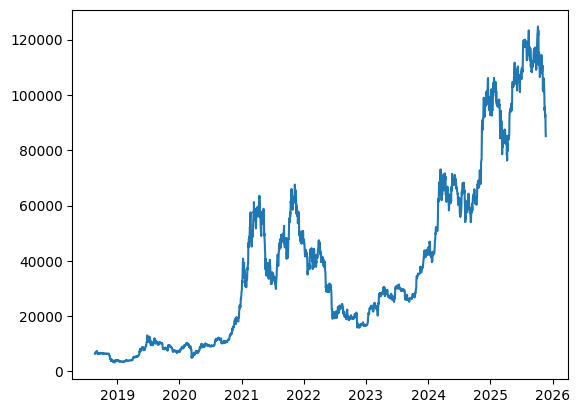

In [17]:
plt.plot(data['priceClose'])
